# Feature-axis validation — merged CircuitNet-N14 + N28

Cross-node replication of the per-dataset analyses. Both N14 and N28 factorial
design matrices are parsed into a **single unified schema**, then run through
the same PCA → η² decomposition → clustering (K-means + Ward) →
per-cluster distribution → kNN label agreement pipeline used in the
per-dataset notebooks. The additional question here is: **does the
technology node (28nm vs 14nm) dominate as a cross-cutting FL client axis on
top of `design_name`?**

## Workflow

1. Parse N28 and N14 filenames with two dedicated parsers, then concat into
   one dataframe with the unified schema.
2. One-hot `design_name` + `filler_insertion` + `tech_node`, QuantileTransform
   + StandardScaler + 15-component PCA.
3. Loadings + recolored PC1/PC2 scatter (with `tech_node` as an extra colouring).
4. Variance-weighted η² decomposition.
5. Clustering + neighbourhood probes: K-means (sweep + manual k), Ward,
   per-cluster distribution, kNN label agreement.
6. Final verdict + N14/N28 cross-comparison.

# Imports

In [ ]:
import os, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mcm

from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# 3D plot of the first three PCs, colored by cluster label and by two key metadata factors
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def _scatter3d(ax, values, cmap, title, cbar_ticks=None, cbar_labels=None):
    sc = ax.scatter(Z3[:, 0], Z3[:, 1], Z3[:, 2], c=values, cmap=cmap,
                    s=6, alpha=0.7, edgecolor='none', depthshade=False)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
    ax.set_title(title)
    cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.08,
                        ticks=cbar_ticks)
    if cbar_labels is not None:
        cbar.set_ticklabels(cbar_labels)
        cbar.ax.tick_params(labelsize=7)

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True, 'grid.color': 'white', 'grid.linewidth': 0.8,
    'axes.facecolor': '#f5f5f5', 'figure.facecolor': 'white',
})

N28_DIR = '../routability_ir_drop_prediction/training_set_N28/DRC/feature'
N14_DIR = '../routability_ir_drop_prediction/training_set_N14/DRC/feature'
SEED = 42
print('Imports OK.')

Imports OK.


# Parse filenames → unified factorial design matrix

In [ ]:
def parse_n28(filename: str) -> dict:
    basename = filename.replace('.npy', '')
    parts = basename.split('-')
    if parts[0].isdigit():
        parts = parts[1:]
    for expected, token in zip(['c', 'u', 'm', 'p', 'f'], parts[-5:]):
        if not token.startswith(expected):
            raise ValueError(f'Bad token {token} in {filename}')
    c, u, m, p, f = parts[-5:]
    clock_ns = float(c[1:])
    fi_raw = f[1:]
    design_name = '-'.join(parts[:-6])
            
    return {
        'design_name':      design_name,  # keep -a/-b (Q1 = b)
        'freq_mhz':         1000.0 / clock_ns,     # Q2 = a
        'macro_placement':  m[1:],
        'utilization':      float(u[1:]),          # already fraction
        'aspect_ratio':     1.0,                   # Q4 = a (impute square)
        'power_mesh':       p[1:],
        'filler_insertion': fi_raw,  # Q6 = a
        'tech_node':        '28nm',                # Q8 = a
        'dataset':          'N28',
        'filename':         filename,
    }


def parse_n14(filename: str) -> dict:
    basename = filename.removesuffix('.npy')
    design_name, sep, rest = basename.partition('_freq_')
    parts = rest.split('_')
    if not (design_name and sep and len(parts) == 11):
        raise ValueError(f'Cannot parse {filename}')
    for expected, token in zip(['mp', 'fpu', 'fpa', 'p', 'fi'], parts[1::2]):
        if token != expected:
            raise ValueError(f'Bad token {token} in {filename}')
    mp, u, ar, pm, fi = parts[2::2]
    return {
        'design_name':      design_name,
        'freq_mhz':         float(parts[0]),
        'macro_placement':  mp,
        'utilization':      float(u) / 100.0,
        'aspect_ratio':     float(ar),
        'power_mesh':       pm,
        'filler_insertion': 1 if fi == 'ap' else 0,
        'tech_node':        '14nm',
        'dataset':          'N14',
        'filename':         filename,
    }


n28_files = sorted(f for f in os.listdir(N28_DIR) if f.endswith('.npy'))
n14_files = sorted(f for f in os.listdir(N14_DIR) if f.endswith('.npy'))

rows = [parse_n28(f) for f in n28_files] + [parse_n14(f) for f in n14_files]
df_meta = pd.DataFrame(rows)
df_meta.loc[~df_meta['macro_placement'].isin(['1', '2', '3', '4']),
            'macro_placement'] = '1'

FACTOR_COLS = [
    'design_name',
    'freq_mhz',
    'macro_placement',
    'utilization',
    'aspect_ratio',
    'power_mesh',
    'filler_insertion',
    'tech_node',
]
print(f'Total samples: {len(df_meta)}   '
      f'(N28: {(df_meta.dataset == "N28").sum()},   '
      f'N14: {(df_meta.dataset == "N14").sum()})')
print('\nUnique-value counts per factor:')
for c in FACTOR_COLS:
    n = df_meta[c].nunique()
    print(f'  {c:20s} {n:3d}')

print('\nHead:')
print(df_meta[FACTOR_COLS + ['dataset']].head(3))
print('\nTail:')
print(df_meta[FACTOR_COLS + ['dataset']].tail(3))

print('\nSanity — cross-node overlap of shared factor levels:')
for c in ['design_name', 'freq_mhz', 'macro_placement',
          'utilization', 'aspect_ratio', 'power_mesh', 'filler_insertion']:
    n28_vals = set(df_meta.loc[df_meta.dataset == 'N28', c].astype(str).unique())
    n14_vals = set(df_meta.loc[df_meta.dataset == 'N14', c].astype(str).unique())
    shared   = sorted(n28_vals & n14_vals)
    n28_only = sorted(n28_vals - n14_vals)
    n14_only = sorted(n14_vals - n28_vals)
    print(f'  {c:20s} shared={shared}   N28-only={n28_only}   N14-only={n14_only}')

Total samples: 19787   (N28: 10242,   N14: 9545)

Unique-value counts per factor:
  design_name           11
  freq_mhz               3
  macro_placement        4
  utilization            9
  aspect_ratio           3
  power_mesh             9
  filler_insertion       4
  tech_node              2

Head:
  design_name  freq_mhz macro_placement  utilization  aspect_ratio power_mesh  \
0     RISCY-a     500.0               1         0.70           1.0          1   
1     RISCY-a     500.0               2         0.70           1.0          2   
2     RISCY-a     500.0               2         0.85           1.0          3   

  filler_insertion tech_node dataset  
0                0      28nm     N28  
1                0      28nm     N28  
2                0      28nm     N28  

Tail:
      design_name  freq_mhz macro_placement  utilization  aspect_ratio  \
19784  zero-riscy      50.0               4         0.75           2.0   
19785  zero-riscy      50.0               4         0.75   

# Factor level frequencies

In [ ]:
DATASETS   = ['N28', 'N14']
BAR_COLORS = {'N28': '#3b6ea5', 'N14': '#d97706'}


def factor_levels(series):
    """Level labels of a factor, numerically ordered when possible."""
    vals = series.astype(str).unique()
    try:
        return sorted(vals, key=float)
    except ValueError:
        return sorted(vals)


def frequency_table(df, col):
    """Sample count per level of `col`, split by source dataset."""
    levels = factor_levels(df[col])
    ct = (pd.crosstab(df[col].astype(str), df['dataset'])
            .reindex(levels).fillna(0).astype(int))
    for ds in DATASETS:
        if ds not in ct.columns:
            ct[ds] = 0
    ct = ct[DATASETS]
    ct['total']   = ct.sum(axis=1)
    ct['percent'] = (ct['total'] / len(df) * 100).round(2)
    ct.index.name = col
    return ct


def print_frequency_tables(df, factor_cols):
    print('=' * 72)
    print(f'Factor level frequencies   (n = {len(df)} samples: '
          f'N28 = {(df.dataset == "N28").sum()}, N14 = {(df.dataset == "N14").sum()})')
    print('=' * 72)
    balance = []
    for f in factor_cols:
        tbl = frequency_table(df, f)
        print(f'\n--- {f}   ({len(tbl)} levels) ---')
        print(tbl.to_string())
        shared = int(((tbl['N28'] > 0) & (tbl['N14'] > 0)).sum())
        balance.append({
            'factor':        f,
            'levels':        len(tbl),
            'shared_levels': shared,
            'min_count':     int(tbl['total'].min()),
            'max_count':     int(tbl['total'].max()),
            'imbalance':     round(tbl['total'].max() / max(tbl['total'].min(), 1), 2),
        })
    print('\n--- balance summary   (imbalance = max/min pooled level count) ---')
    print(pd.DataFrame(balance).set_index('factor').to_string())


def plot_factor_frequencies(df, factor_cols, ncols=4):
    nrows = int(np.ceil(len(factor_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3.8 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, f in zip(axes, factor_cols):
        tbl = frequency_table(df, f)
        levels = [str(x) for x in tbl.index]
        xs = np.arange(len(levels))
        width = 0.38
        for i, ds in enumerate(DATASETS):
            ax.bar(xs + (i - 0.5) * width, tbl[ds], width * 0.92,
                   color=BAR_COLORS[ds], edgecolor='white', linewidth=0.8,
                   label=ds)
        ax.set_xticks(xs)
        ax.set_xticklabels(levels)
        if max(len(l) for l in levels) > 6:
            ax.tick_params(axis='x', labelrotation=40)
            for lab in ax.get_xticklabels():
                lab.set_ha('right')
        ax.set_title(f'{f}   ({len(levels)} levels)')
        ax.set_ylabel('samples')
        ax.set_ylim(0, tbl[DATASETS].to_numpy().max() * 1.16)
        ax.set_axisbelow(True)
        ax.xaxis.grid(False)
        ax.legend(fontsize=7, frameon=False)
    for ax in axes[len(factor_cols):]:
        ax.axis('off')
    fig.suptitle('Sample count per factor level, by source dataset   '
                 f'(n = {len(df)})', y=1.02)
    plt.tight_layout(); plt.show()


print_frequency_tables(df_meta, FACTOR_COLS)
plot_factor_frequencies(df_meta, FACTOR_COLS)

# Preprocess + PCA

Design-matrix columns:
  freq_mhz
  macro_placement
  utilization
  aspect_ratio
  power_mesh
  filler_insertion
  design_name_RISCY
  design_name_RISCY-FPU
  design_name_RISCY-FPU-a
  design_name_RISCY-FPU-b
  design_name_RISCY-a
  design_name_RISCY-b
  design_name_Vortex-small
  design_name_nvdla-small
  design_name_zero-riscy
  design_name_zero-riscy-a
  design_name_zero-riscy-b
  tech_node_14nm
  tech_node_28nm

Explained variance ratio (19 components):
  PC 1: 0.223   cumulative=0.223
  PC 2: 0.064   cumulative=0.287
  PC 3: 0.063   cumulative=0.349
  PC 4: 0.062   cumulative=0.412
  PC 5: 0.059   cumulative=0.471
  PC 6: 0.059   cumulative=0.529
  PC 7: 0.058   cumulative=0.588
  PC 8: 0.057   cumulative=0.645
  PC 9: 0.056   cumulative=0.701
  PC10: 0.053   cumulative=0.754
  PC11: 0.052   cumulative=0.806
  PC12: 0.048   cumulative=0.854
  PC13: 0.046   cumulative=0.900
  PC14: 0.045   cumulative=0.945
  PC15: 0.032   cumulative=0.977
  PC16: 0.023   cumulative=1.000
  PC17: 0.

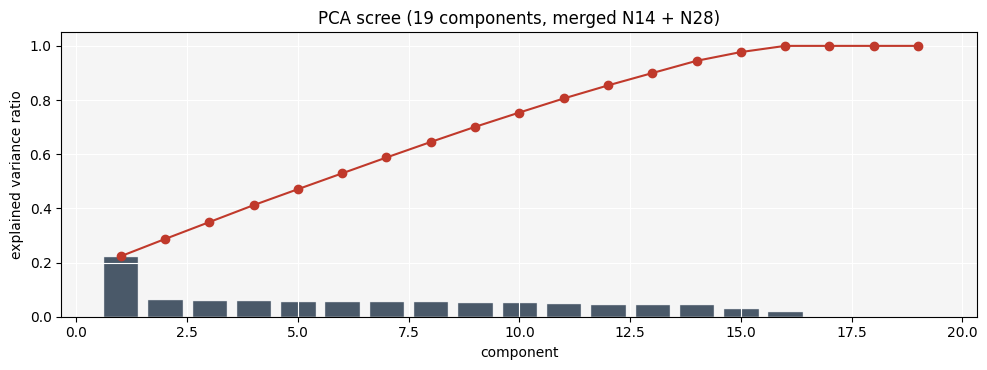

In [28]:
subset = df_meta
new_subset = pd.get_dummies(
    subset,
    columns=['design_name', 'tech_node'],
    dtype='uint8',
)
new_subset = new_subset.drop(columns=['filename', 'dataset'])
print('Design-matrix columns:')
for c in new_subset.columns:
    print(f'  {c}')

X = new_subset[new_subset.columns].to_numpy()

qt = QuantileTransformer(output_distribution='normal', random_state=SEED,
                         n_quantiles=min(1000, len(X)))
X_qt = qt.fit_transform(X)
sc = StandardScaler()
X_std = sc.fit_transform(X_qt)

N_PC = X_std.shape[1]
pca = PCA(n_components=N_PC, random_state=SEED)
Z = pca.fit_transform(X_std)
evr = pca.explained_variance_ratio_
print(f'\nExplained variance ratio ({N_PC} components):')
for i, v in enumerate(evr):
    print(f'  PC{i + 1:2d}: {v:.3f}   cumulative={evr[:i + 1].sum():.3f}')

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.bar(range(1, N_PC + 1), evr, alpha=0.85, color='#2c3e50', edgecolor='white')
ax.plot(range(1, N_PC + 1), np.cumsum(evr), marker='o', color='#c0392b')
ax.set_xlabel('component'); ax.set_ylabel('explained variance ratio')
ax.set_title(f'PCA scree ({N_PC} components, merged N14 + N28)')
plt.tight_layout(); plt.show()

# PC loadings + recolored PC1/PC2/PC3 scatter


Top-10 |loadings| on PC1:
  +0.474  tech_node_14nm
  -0.474  tech_node_28nm
  +0.364  aspect_ratio
  -0.322  utilization
  +0.215  design_name_RISCY-FPU
  +0.214  design_name_zero-riscy
  +0.213  design_name_RISCY
  -0.200  power_mesh
  -0.153  design_name_zero-riscy-a
  -0.152  design_name_RISCY-b

Top-10 |loadings| on PC2:
  +0.488  filler_insertion
  +0.440  design_name_RISCY-FPU-b
  -0.404  macro_placement
  +0.310  design_name_zero-riscy-b
  -0.287  design_name_zero-riscy-a
  -0.281  design_name_RISCY-FPU-a
  -0.278  design_name_RISCY-a
  +0.176  design_name_RISCY-b
  +0.089  design_name_Vortex-small
  +0.080  design_name_zero-riscy

Top-10 |loadings| on PC3:
  +0.755  design_name_zero-riscy
  -0.637  design_name_RISCY-FPU
  -0.121  design_name_RISCY
  -0.044  design_name_RISCY-FPU-b
  +0.041  macro_placement
  -0.035  filler_insertion
  +0.032  design_name_zero-riscy-a
  -0.030  design_name_zero-riscy-b
  +0.030  design_name_RISCY-FPU-a
  +0.030  design_name_RISCY-a


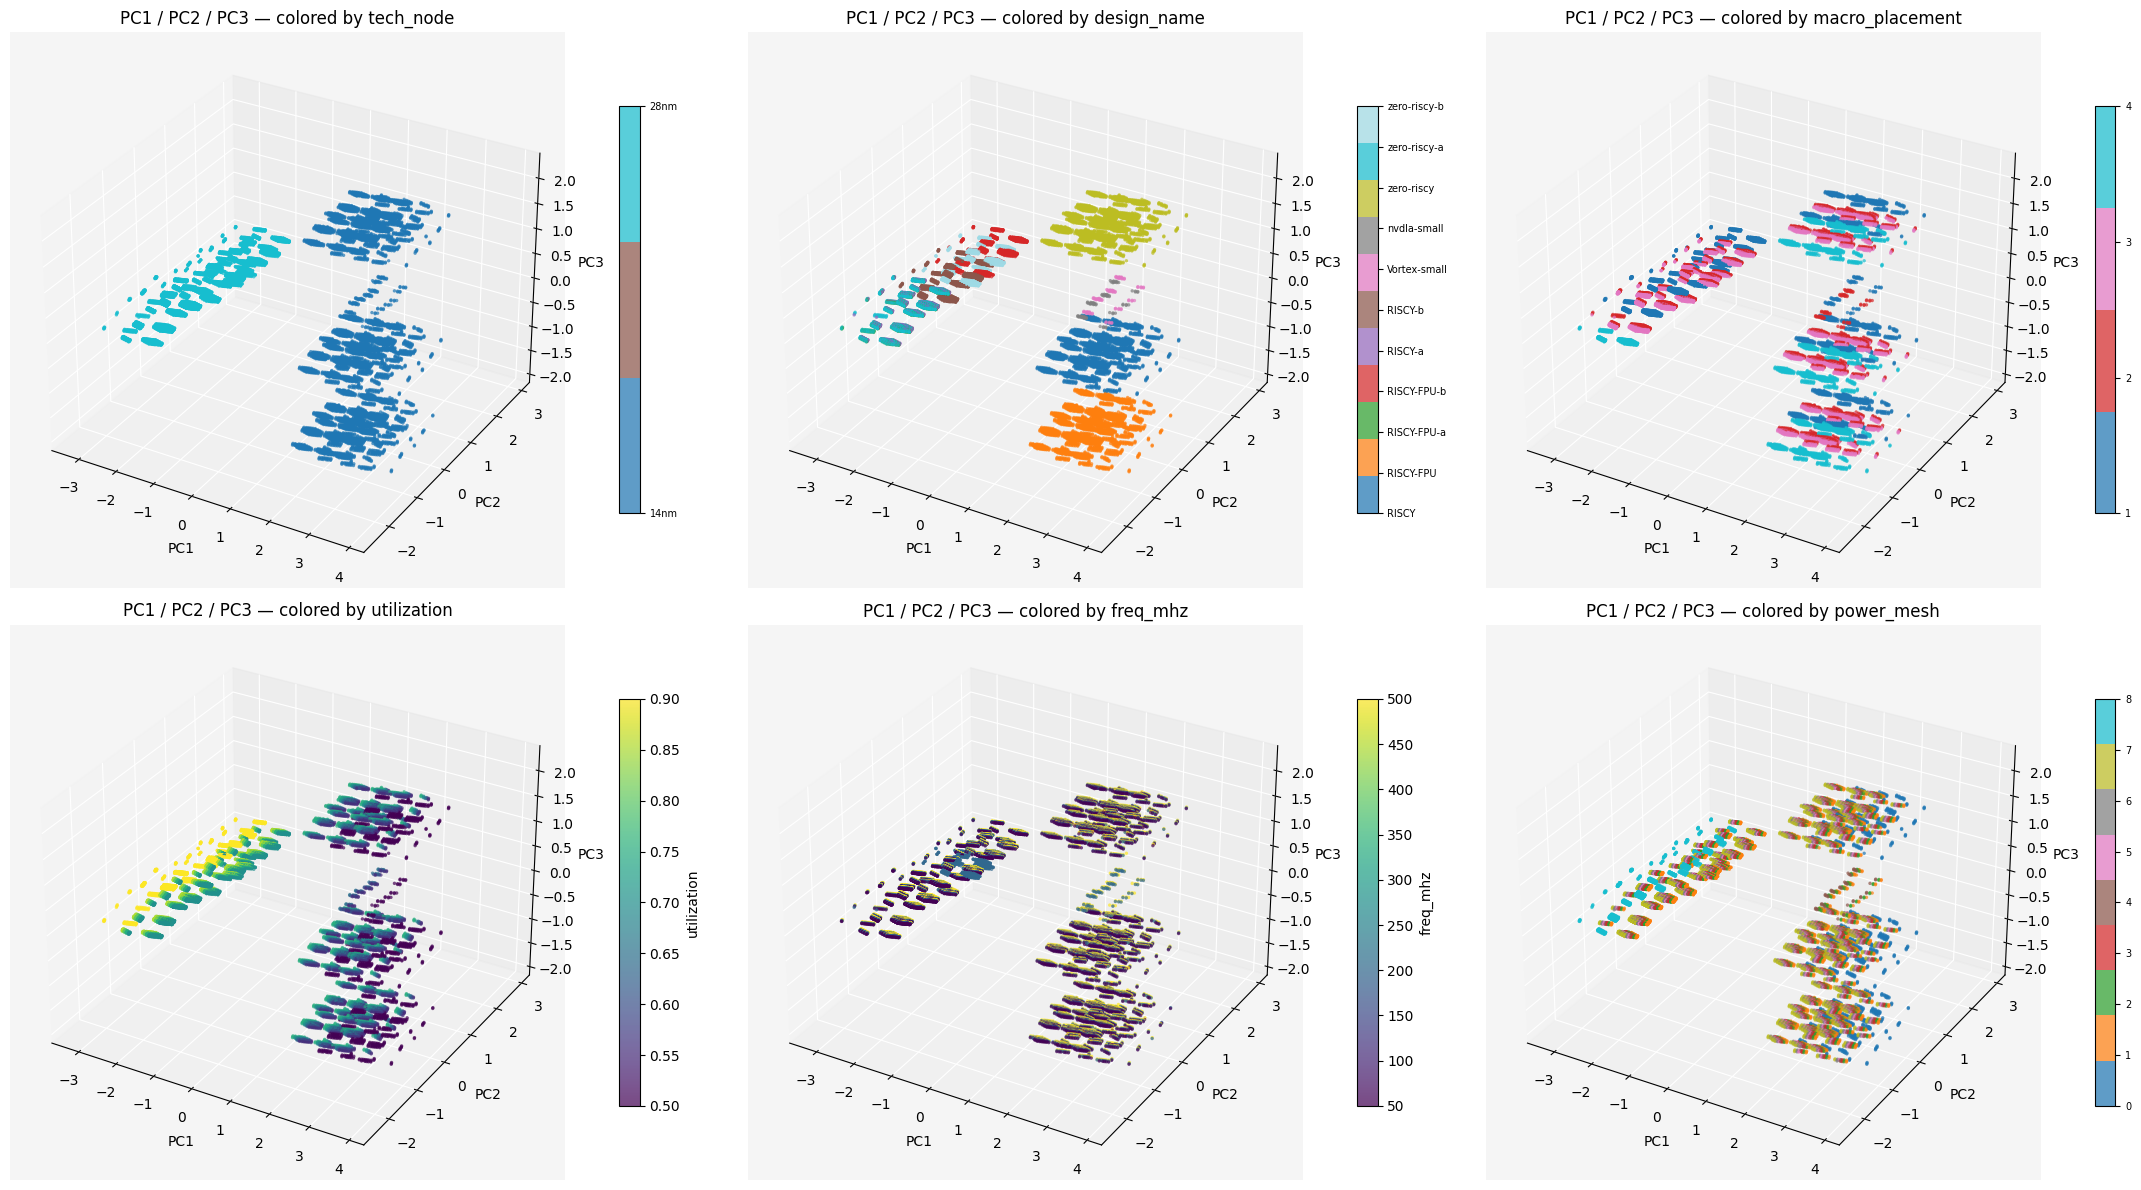

In [ ]:
loadings = pd.DataFrame(pca.components_.T, index=new_subset.columns,
                        columns=[f'PC{i + 1}' for i in range(pca.n_components_)])

for pc in ['PC1', 'PC2', 'PC3']:
    top = loadings[pc].abs().sort_values(ascending=False).head(10)
    print(f'\nTop-10 |loadings| on {pc}:')
    for name in top.index:
        print(f'  {loadings.loc[name, pc]:+.3f}  {name}')

recolor_factors = ['tech_node', 'design_name', 'macro_placement',
                   'utilization', 'freq_mhz', 'power_mesh']

fig = plt.figure(figsize=(22, 12))
for i, factor in enumerate(recolor_factors):
    ax = fig.add_subplot(2, 3, i + 1, projection='3d')
    if pd.api.types.is_numeric_dtype(subset[factor]):
        codes = subset[factor].to_numpy()
        sc_ = ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c=codes, cmap='viridis',
                         s=6, alpha=0.7, edgecolor='none', depthshade=False)
        plt.colorbar(sc_, ax=ax, fraction=0.03, pad=0.08, label=factor)
    else:
        levels = sorted(subset[factor].astype(str).unique())
        code_map = {l: i for i, l in enumerate(levels)}
        codes = subset[factor].astype(str).map(code_map).to_numpy()
        cmap = mcm.get_cmap('tab10' if len(levels) <= 10 else 'tab20',
                            max(len(levels), 3))
        sc_ = ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c=codes, cmap=cmap,
                         s=6, alpha=0.7, edgecolor='none', depthshade=False,
                         vmin=0, vmax=max(len(levels) - 1, 1))
        cbar = plt.colorbar(sc_, ax=ax, ticks=range(len(levels)),
                            fraction=0.03, pad=0.08)
        cbar.set_ticklabels(levels)
        cbar.ax.tick_params(labelsize=7)
    ax.set_title(f'PC1 / PC2 / PC3 — colored by {factor}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
plt.tight_layout()
plt.show()

df_full = subset

# Variance decomposition — variance-weighted η²

          factor  n_levels  eta2_PC1  eta2_PC2  eta2_PC3  eta2_PC4  eta2_PC5  eta2_PC6  eta2_PC7  eta2_PC8  eta2_PC9  eta2_PC10  eta2_PC11  eta2_PC12  eta2_PC13  eta2_PC14  eta2_PC15  eta2_PC16  eta2_PC17  eta2_PC18  eta2_PC19  weighted_total
     design_name        11     0.954     0.648     0.997     0.999     0.915     0.961     0.997     0.795     0.975      0.980      0.200      0.312      0.017      0.170      0.035      0.044        0.0        0.0      0.000           0.735
       tech_node         2     0.952     0.003     0.000     0.000     0.000     0.000     0.000     0.001     0.000      0.000      0.000      0.000      0.004      0.000      0.007      0.032        0.0        0.0      0.000           0.214
     utilization         9     0.674     0.023     0.000     0.000     0.004     0.002     0.000     0.011     0.006      0.001      0.011      0.003      0.025      0.002      0.622      0.080        0.0        0.0      0.001           0.177
    aspect_ratio         3  

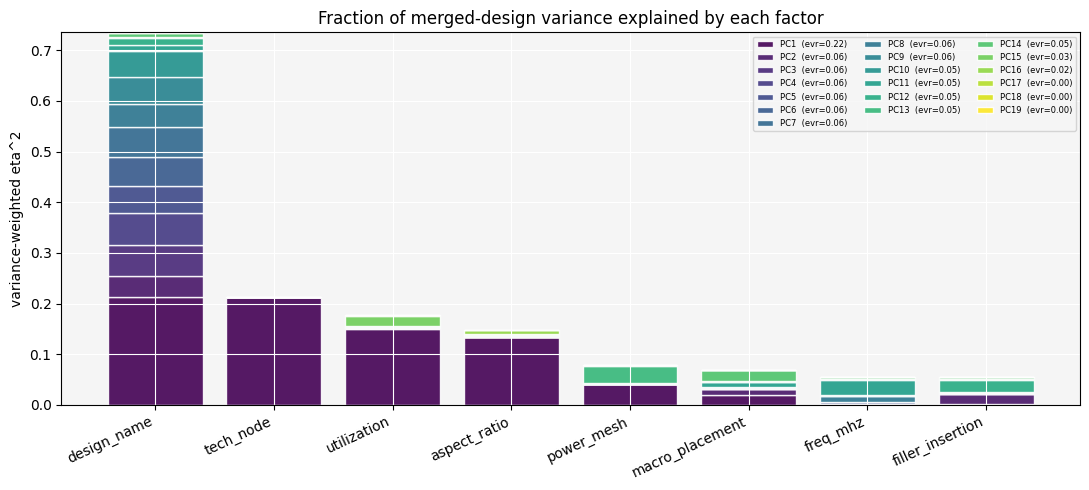

In [30]:
def eta_sq(y_num, groups):
    d = pd.DataFrame({'y': y_num, 'g': groups}).dropna()
    grand = d['y'].mean()
    ss_tot = ((d['y'] - grand) ** 2).sum()
    if ss_tot == 0:
        return 0.0
    ss_bet = sum(len(g) * (g['y'].mean() - grand) ** 2
                 for _, g in d.groupby('g'))
    return float(ss_bet / ss_tot)


K_PC = pca.n_components_
eta_rows = []
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    groups = df_full[f].astype(str).to_numpy()
    row = {'factor': f, 'n_levels': int(df_full[f].nunique())}
    for k in range(K_PC):
        row[f'eta2_PC{k + 1}'] = round(eta_sq(Z[:, k], groups), 3)
    row['weighted_total'] = round(sum(
        row[f'eta2_PC{k + 1}'] * evr[k] for k in range(K_PC)
    ), 3)
    eta_rows.append(row)
eta_df = pd.DataFrame(eta_rows).sort_values('weighted_total', ascending=False)
print(eta_df.to_string(index=False))

top_factors = eta_df['factor'].tolist()
fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(top_factors))
cmap = mcm.get_cmap('viridis', K_PC)
for k in range(K_PC):
    heights = np.array([
        eta_df.set_index('factor').loc[f, f'eta2_PC{k + 1}'] * evr[k]
        for f in top_factors
    ])
    ax.bar(top_factors, heights, bottom=bottom, color=cmap(k),
           label=f'PC{k + 1}  (evr={evr[k]:.2f})',
           edgecolor='white', alpha=0.9)
    bottom += heights
ax.set_ylabel('variance-weighted eta^2')
ax.set_title('Fraction of merged-design variance explained by each factor')
ax.legend(fontsize=6, loc='upper right', ncol=3)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

# Clustering + neighborhood diagnostics

## K-means — k sweep + label agreement

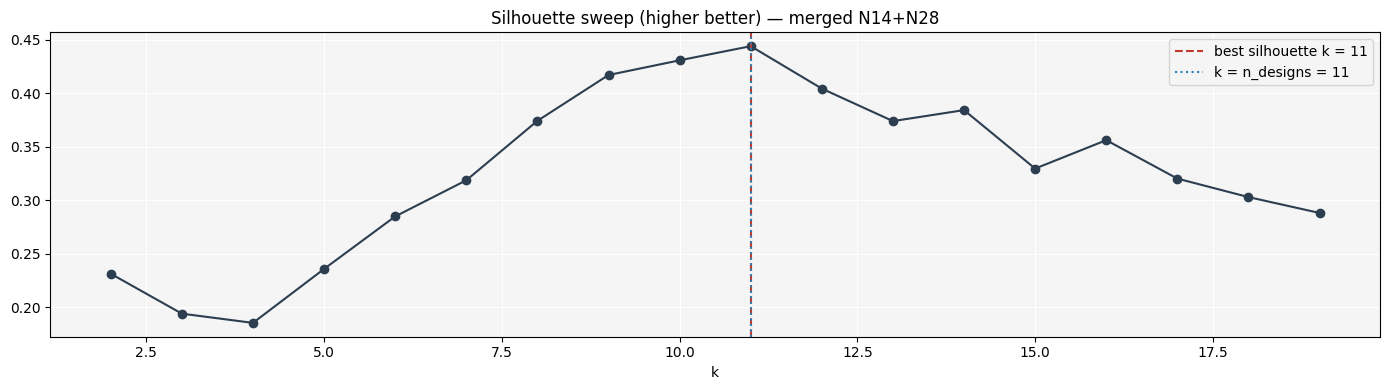

Best-silhouette k = 11   (silhouette = 0.444)
n_designs      k = 11   (silhouette = 0.444)


In [31]:
Z3 = Z  # full PC space, name kept for parity with per-dataset notebooks
k_design = df_full['design_name'].nunique()

ks = list(range(2, 20))
sil = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    lab = km.fit_predict(Z3)
    sil.append(silhouette_score(Z3, lab))

k_best_sil = ks[int(np.argmax(sil))]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ks, sil, marker='o', color='#2c3e50')
ax.axvline(k_best_sil, ls='--', color='#c0392b',
           label=f'best silhouette k = {k_best_sil}')
ax.axvline(k_design, ls=':', color='#2980b9',
           label=f'k = n_designs = {k_design}')
ax.set_title('Silhouette sweep (higher better) — merged N14+N28')
ax.set_xlabel('k'); ax.legend()
plt.tight_layout(); plt.show()

print(f'Best-silhouette k = {k_best_sil}   (silhouette = {max(sil):.3f})')
print(f'n_designs      k = {k_design}   (silhouette = {sil[ks.index(k_design)]:.3f})')

In [32]:
# SET K HERE
k_design = k_best_sil
print(f'Using k_design = {k_design} for clustering and evaluation.')

Using k_design = 11 for clustering and evaluation.



ARI / NMI of k-means labels (k=11) vs each metadata factor:
  design_name          ARI=+1.000  NMI=1.000
  freq_mhz             ARI=+0.002  NMI=0.011
  macro_placement      ARI=+0.004  NMI=0.033
  utilization          ARI=+0.058  NMI=0.204
  aspect_ratio         ARI=+0.033  NMI=0.212
  power_mesh           ARI=+0.009  NMI=0.044
  filler_insertion     ARI=+0.001  NMI=0.006
  tech_node            ARI=+0.243  NMI=0.483


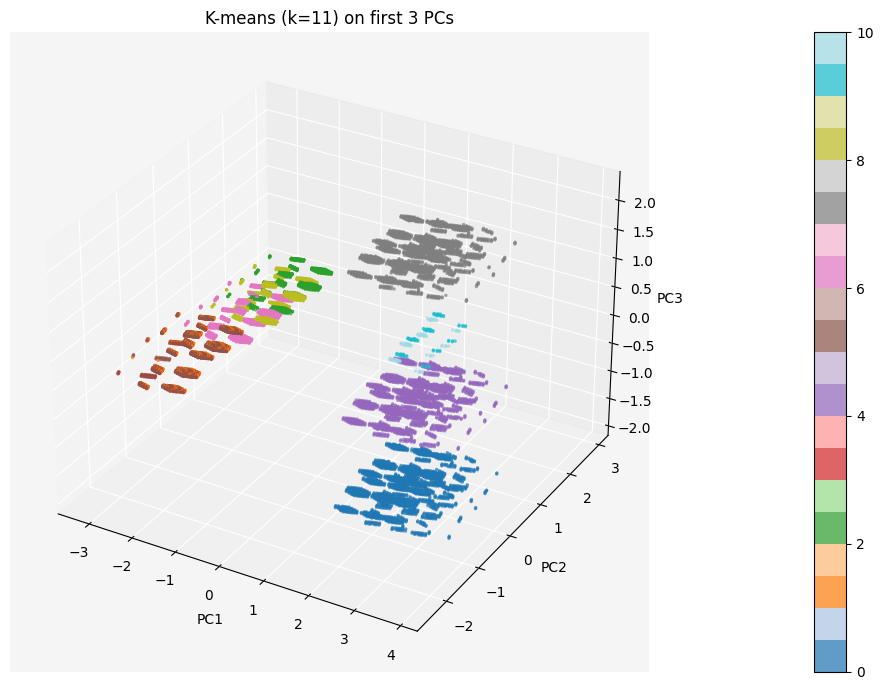

In [33]:
km = KMeans(n_clusters=k_design, n_init=10, random_state=SEED)
lab_km = km.fit_predict(Z3)
print(f'\nARI / NMI of k-means labels (k={k_design}) vs each metadata factor:')
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    y = df_full[f].astype(str).to_numpy()
    ari = adjusted_rand_score(y, lab_km)
    nmi = normalized_mutual_info_score(y, lab_km)
    print(f'  {f:20s} ARI={ari:+.3f}  NMI={nmi:.3f}')

fig = plt.figure(figsize=(21, 7))

_scatter3d(fig.add_subplot(1, 1, 1, projection='3d'),
           lab_km, 'tab20',
           f'K-means (k={k_design}) on first 3 PCs')

plt.tight_layout()
plt.show()

## Hierarchical (Ward) — dendrogram + label agreement

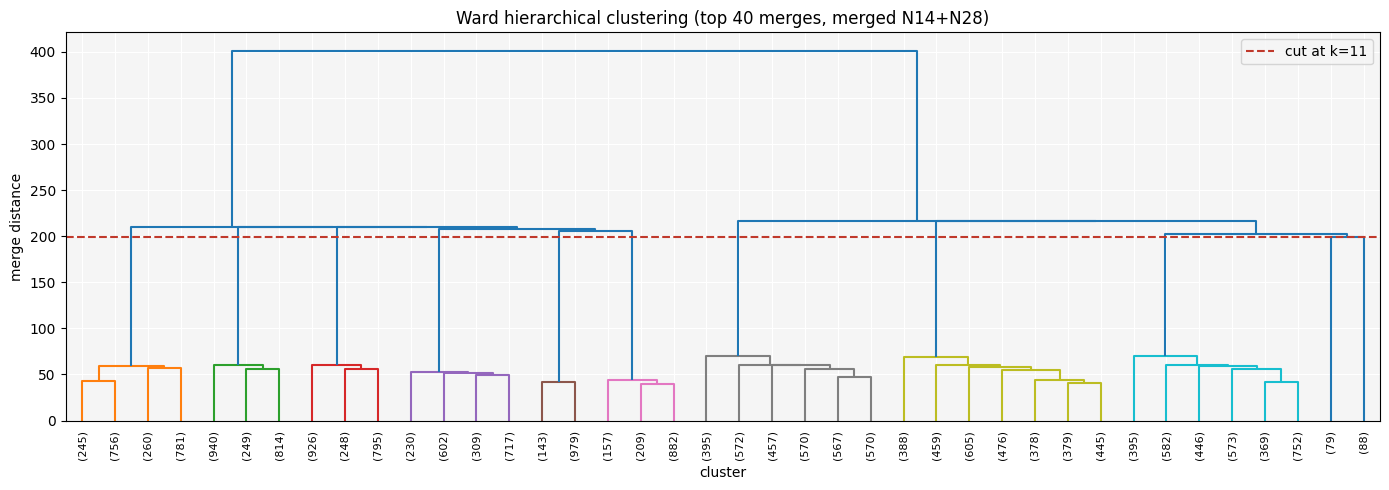

Hierarchical @ k=11   silhouette = 0.444   (k-means @ k=11 silhouette = 0.444)

ARI / NMI of hierarchical labels (k=11) vs each metadata factor:
  design_name          ARI=+1.000  NMI=1.000
  freq_mhz             ARI=+0.002  NMI=0.011
  macro_placement      ARI=+0.004  NMI=0.033
  utilization          ARI=+0.058  NMI=0.204
  aspect_ratio         ARI=+0.033  NMI=0.212
  power_mesh           ARI=+0.009  NMI=0.044
  filler_insertion     ARI=+0.001  NMI=0.006
  tech_node            ARI=+0.243  NMI=0.483


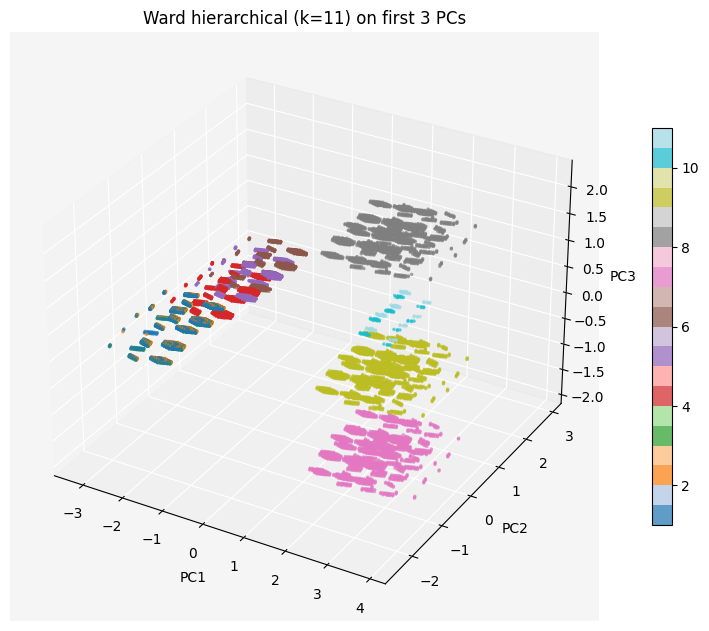

In [37]:
Z_link = linkage(Z3, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z_link, truncate_mode='lastp', p=40,
           leaf_rotation=90, leaf_font_size=8, ax=ax,
           color_threshold=Z_link[-(k_design - 1), 2])
ax.axhline(Z_link[-(k_design - 1), 2], ls='--', color='#c0392b',
           label=f'cut at k={k_design}')
ax.set_title(f'Ward hierarchical clustering (top 40 merges, merged N14+N28)')
ax.set_xlabel('cluster'); ax.set_ylabel('merge distance')
ax.legend()
plt.tight_layout(); plt.show()

lab_hier = fcluster(Z_link, t=k_design, criterion='maxclust')
sil_hier = silhouette_score(Z3, lab_hier)
print(f'Hierarchical @ k={k_design}   silhouette = {sil_hier:.3f}   '
      f'(k-means @ k={k_design} silhouette = {sil[ks.index(k_design)]:.3f})')

print(f'\nARI / NMI of hierarchical labels (k={k_design}) vs each metadata factor:')
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    y = df_full[f].astype(str).to_numpy()
    ari = adjusted_rand_score(y, lab_hier)
    nmi = normalized_mutual_info_score(y, lab_hier)
    print(f'  {f:20s} ARI={ari:+.3f}  NMI={nmi:.3f}')

fig = plt.figure(figsize=(21, 7))
_scatter3d(fig.add_subplot(1, 3, 1, projection='3d'),
           lab_hier, 'tab20',
           f'Ward hierarchical (k={k_design}) on first 3 PCs')

plt.tight_layout(); plt.show()

## Per-cluster feature distribution


K-means (k = 11): per-cluster feature distribution

Cluster sizes: {0: 3131, 1: 2003, 2: 1248, 3: 1969, 4: 3117, 5: 2042, 6: 1858, 7: 3130, 8: 1122, 9: 88, 10: 79}   (total = 19787)

--- design_name   (% within each cluster) ---
design_name  RISCY  RISCY-FPU  RISCY-FPU-a  RISCY-FPU-b  RISCY-a  RISCY-b  Vortex-small  nvdla-small  zero-riscy  zero-riscy-a  zero-riscy-b
cluster                                                                                                                                     
0              0.0      100.0          0.0          0.0      0.0      0.0           0.0          0.0         0.0           0.0           0.0
1              0.0        0.0          0.0          0.0    100.0      0.0           0.0          0.0         0.0           0.0           0.0
2              0.0        0.0          0.0        100.0      0.0      0.0           0.0          0.0         0.0           0.0           0.0
3              0.0        0.0        100.0          0.0      0.0 

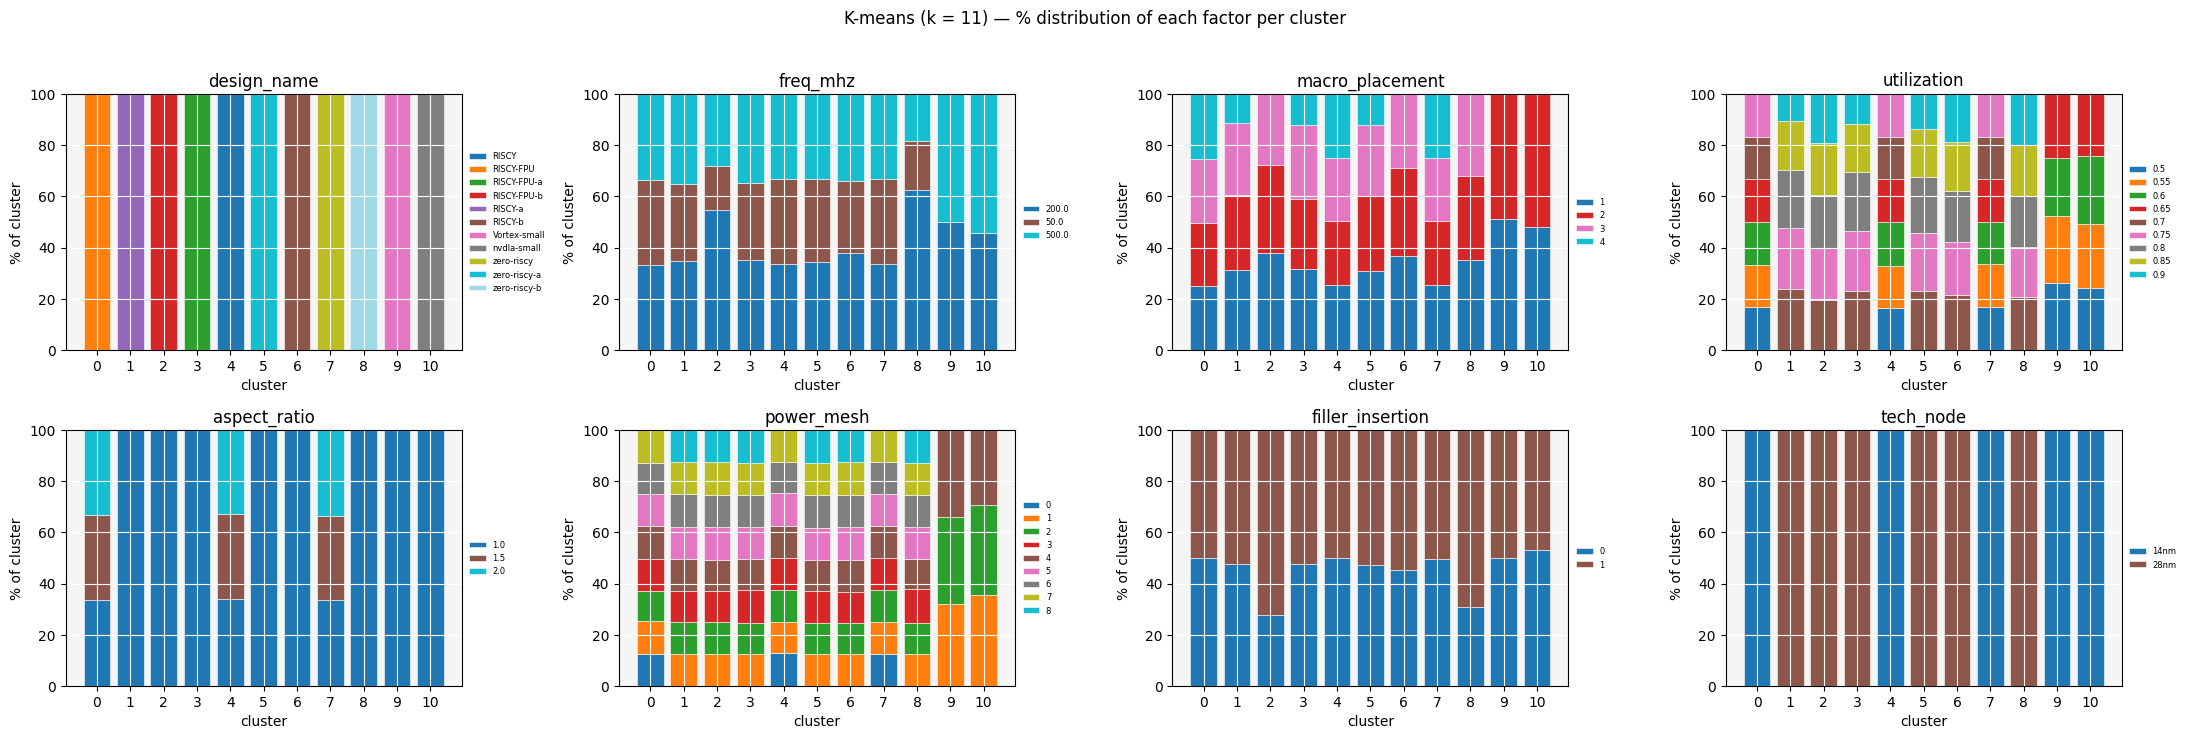

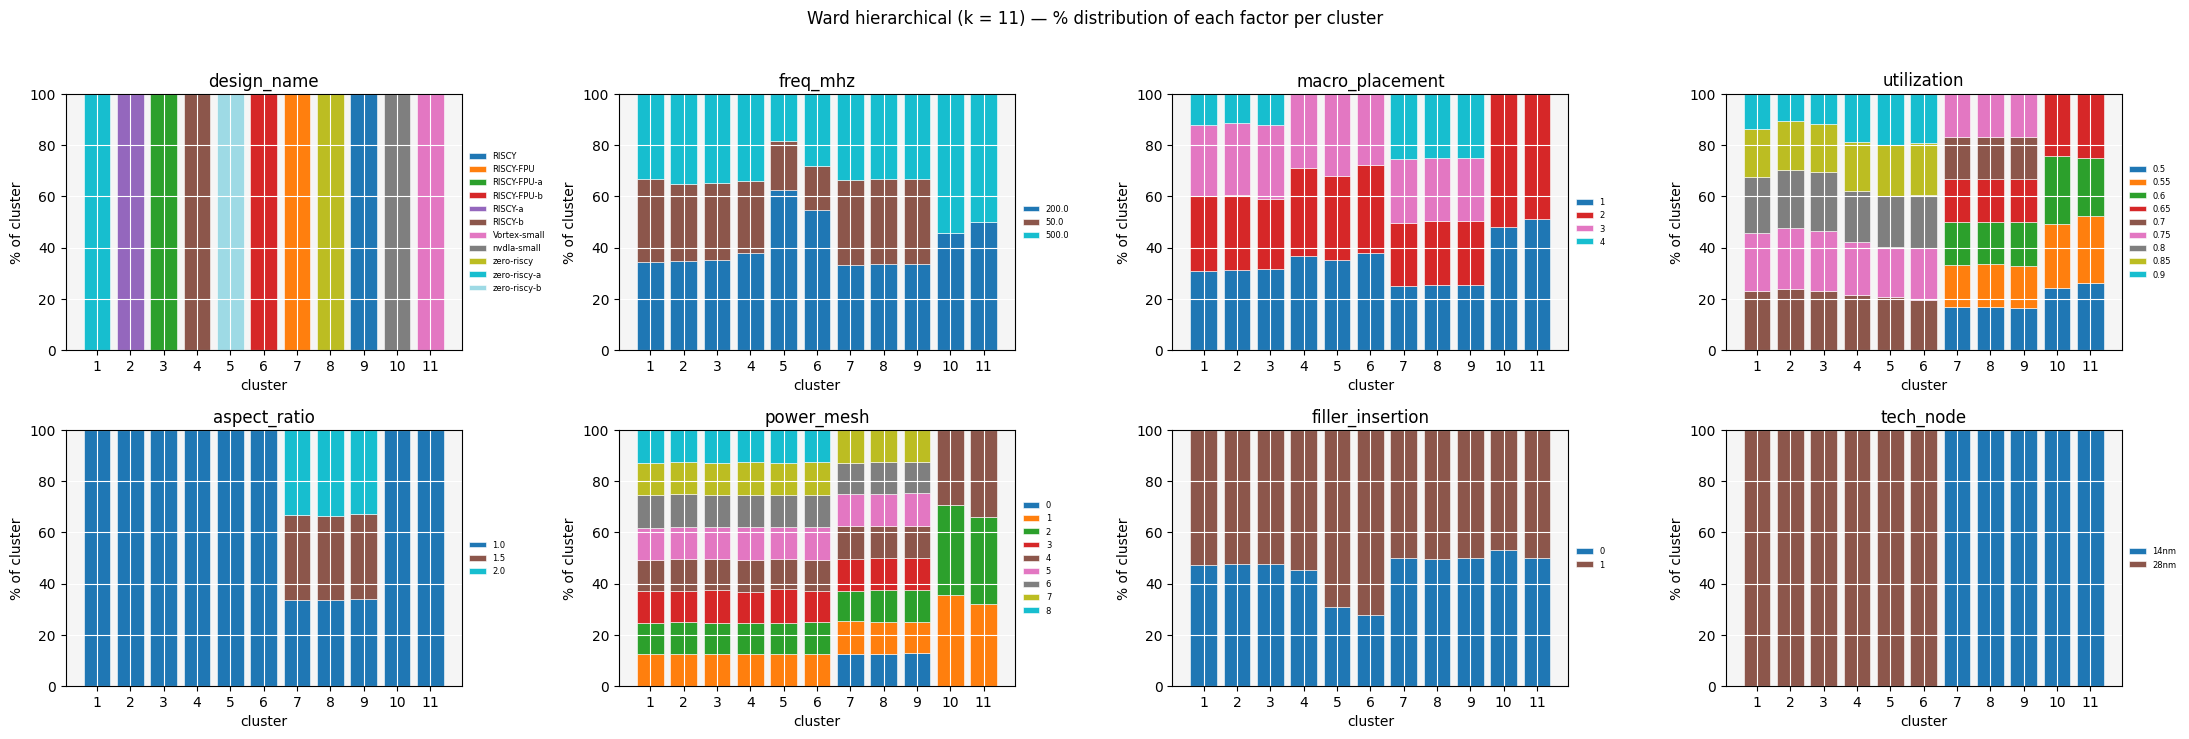

In [35]:
def per_cluster_tables(labels, method_name, df, factor_cols):
    lab_series = pd.Series(labels, name='cluster')
    sizes = lab_series.value_counts().sort_index()
    print(f'\n{"=" * 72}')
    print(f'{method_name}: per-cluster feature distribution')
    print(f'{"=" * 72}')
    print(f'\nCluster sizes: {dict(sizes)}   (total = {sizes.sum()})')
    for f in factor_cols:
        ct = pd.crosstab(lab_series, df[f].astype(str), normalize='index') * 100
        ct = ct.round(1)
        ct.index.name = 'cluster'
        print(f'\n--- {f}   (% within each cluster) ---')
        print(ct.to_string())


def plot_per_cluster(labels, method_name, df, factor_cols, ncols=4):
    cluster_ids = sorted(np.unique(labels))
    nfac = len(factor_cols)
    nrows = int(np.ceil(nfac / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3.6 * nrows))
    axes = axes.ravel()
    for i, f in enumerate(factor_cols):
        ax = axes[i]
        levels = sorted(df[f].astype(str).unique())
        counts = np.zeros((len(cluster_ids), len(levels)))
        for ci, c in enumerate(cluster_ids):
            mask = labels == c
            vc = df.loc[mask, f].astype(str).value_counts()
            for li, l in enumerate(levels):
                counts[ci, li] = vc.get(l, 0)
        row_sums = np.maximum(counts.sum(axis=1, keepdims=True), 1)
        pct = counts / row_sums * 100
        bottom = np.zeros(len(cluster_ids))
        cmap = plt.get_cmap('tab10' if len(levels) <= 10 else 'tab20',
                            max(len(levels), 3))
        xtick = [str(c) for c in cluster_ids]
        for li, l in enumerate(levels):
            ax.bar(xtick, pct[:, li], bottom=bottom, color=cmap(li),
                   label=str(l), edgecolor='white', linewidth=0.4)
            bottom += pct[:, li]
        ax.set_title(f)
        ax.set_xlabel('cluster')
        ax.set_ylabel('% of cluster')
        ax.set_ylim(0, 100)
        ax.legend(fontsize=6, loc='center left', bbox_to_anchor=(1, 0.5),
                  frameon=False)
    for j in range(nfac, len(axes)):
        axes[j].axis('off')
    fig.suptitle(f'{method_name} — % distribution of each factor per cluster',
                 y=1.02)
    plt.tight_layout(); plt.show()


km_name   = f'K-means (k = {len(np.unique(lab_km))})'
hier_name = f'Ward hierarchical (k = {len(np.unique(lab_hier))})'

per_cluster_tables(lab_km,   km_name,   df_full, FACTOR_COLS)
per_cluster_tables(lab_hier, hier_name, df_full, FACTOR_COLS)

plot_per_cluster(lab_km,   km_name,   df_full, FACTOR_COLS)
plot_per_cluster(lab_hier, hier_name, df_full, FACTOR_COLS)

## kNN label agreement

kNN label agreement (k=12, merged N14+N28):

          factor  n_levels  agreement  chance  lift
     design_name        11      1.000   0.091 11.00
     utilization         9      0.527   0.111  4.74
      power_mesh         9      0.485   0.111  4.37
filler_insertion         4      0.999   0.250  4.00
 macro_placement         4      0.803   0.250  3.21
    aspect_ratio         3      0.973   0.333  2.92
        freq_mhz         3      0.961   0.333  2.88
       tech_node         2      1.000   0.500  2.00


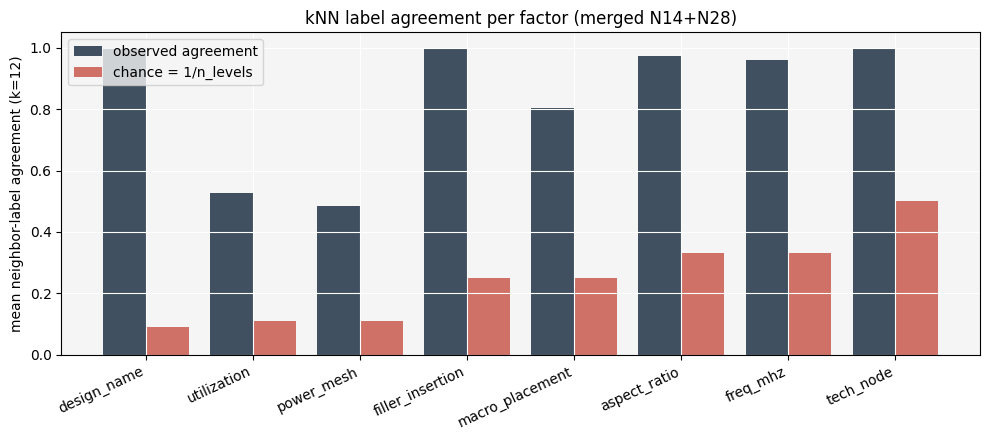

In [36]:
K_NN = 12

nn = NearestNeighbors(n_neighbors=K_NN + 1).fit(Z3)
_, idx = nn.kneighbors(Z3)
neighbor_idx = idx[:, 1:]

rows = []
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    y = df_full[f].astype(str).to_numpy()
    match = (y[neighbor_idx] == y[:, None]).mean(axis=1)
    chance = 1.0 / df_full[f].nunique()
    rows.append({
        'factor':    f,
        'n_levels':  int(df_full[f].nunique()),
        'agreement': round(float(match.mean()), 3),
        'chance':    round(chance, 3),
        'lift':      round(float(match.mean()) / chance, 2),
    })
knn_df = pd.DataFrame(rows).sort_values('lift', ascending=False)
print(f'kNN label agreement (k={K_NN}, merged N14+N28):\n')
print(knn_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(knn_df))
ax.bar(x - 0.2, knn_df['agreement'], width=0.4,
       color='#2c3e50', alpha=0.9, label='observed agreement')
ax.bar(x + 0.2, knn_df['chance'], width=0.4,
       color='#c0392b', alpha=0.7, label='chance = 1/n_levels')
ax.set_xticks(x); ax.set_xticklabels(knn_df['factor'], rotation=25, ha='right')
ax.set_ylabel(f'mean neighbor-label agreement (k={K_NN})')
ax.set_title('kNN label agreement per factor (merged N14+N28)')
ax.legend()
plt.tight_layout(); plt.show()